# U-Net Pipeline Applied

## Set Up

In [1]:
import sys
sys.path.append('.')

import logging
import torch
from pathlib import Path

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [2]:
import train
from unet import UNet

train.dir_img = Path('./data/imgs/')
train.dir_mask = Path('./data/masks/')
train.dir_checkpoint = Path('./checkpoints/')

## Training U-Net Model

In [3]:
model = UNet(n_channels=1, n_classes=6, bilinear=False)   # set n_classes to your actual count
model = model.to(memory_format=torch.channels_last)
model = model.to(device=device)

In [4]:
train.train_model(
    model=model,
    device=device,
    epochs=1,
    batch_size=4,
    learning_rate=1e-5,
    val_percent=0.1,
    img_scale=1.0,
    amp=False,
)

INFO: Creating dataset with 169 examples
INFO: Scanning mask files to determine unique values


100%|██████████| 169/169 [00:04<00:00, 39.09it/s]
INFO: Unique mask values: [0, 1, 2, 3, 4, 5]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id agfxl5ne.


INFO: Starting training:
        Epochs:          1
        Batch size:      4
        Learning rate:   1e-05
        Training size:   75
        Validation size: 94
        Checkpoints:     True
        Device:          cpu
        Images scaling:  1.0
        Mixed Precision: False
    
c:\Users\josep\p4p\p4p\segmentation_project\Pytorch-UNet\train.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
Epoch 1/1:   0%|          | 0/75 [00:00<?, ?img/s]c:\Users\josep\p4p\p4p\segmentation_project\Pytorch-UNet\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/1: 100%|██████████| 75/75 [22:42<00:00, 18.17s/img, loss (batch)=1.62]
INFO: Checkpoint 1 saved!


## Evaluation Final Valdiation Score

In [ ]:
# reconstructing dataset and validation split (what was used internall during training)

import re
import random
from collections import defaultdict
from torch.utils.data import Subset, DataLoader

from utils.data_loading import MRIDataset

# must match what you passed to train_model
img_scale = 1.0
val_percent = 0.1
batch_size = 4

dataset = MRIDataset(train.dir_img, train.dir_mask, scale=img_scale)

patient_ids = defaultdict(list)
for i, id_ in enumerate(dataset.ids):
    match = re.match(r'^(CADRE_\d{4})\d+$', id_)
    assert match, f'Unexpected filename pattern: {id_}'
    patient_ids[match.group(1)].append(i)

patients = list(patient_ids.keys())
random.Random(0).shuffle(patients)
n_val_patients = max(1, int(len(patients) * val_percent))
val_patients = set(patients[:n_val_patients])

val_idx = [i for p in val_patients for i in patient_ids[p]]
val_set = Subset(dataset, val_idx)
val_loader = DataLoader(val_set, shuffle=False, drop_last=True, batch_size=batch_size, num_workers=0, pin_memory=True)

print(f'{len(dataset.mask_values)} mask values: {dataset.mask_values}')
print(f'{len(val_set)} validation slices')

INFO: Creating dataset with 169 examples
INFO: Scanning mask files to determine unique values
100%|██████████| 169/169 [00:05<00:00, 32.86it/s]
INFO: Unique mask values: [0, 1, 2, 3, 4, 5]


6 mask values: [0, 1, 2, 3, 4, 5]
94 validation slices


In [6]:
from evaluate import evaluate

val_score = evaluate(model, val_loader, device, amp=False)
print(f'Final validation Dice score: {val_score:.4f}')

Validation round:   0%|          | 0/23 [00:00<?, ?batch/s]c:\Users\josep\p4p\p4p\segmentation_project\Pytorch-UNet\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                                    

Final validation Dice score: 0.1639


In [ ]:
# saving trained model
dir_checkpoint = train.dir_checkpoint
dir_checkpoint.mkdir(parents=True, exist_ok=True)

state_dict = model.state_dict()
state_dict['mask_values'] = dataset.mask_values
torch.save(state_dict, dir_checkpoint / 'model_final.pth')
print('Saved to', dir_checkpoint / 'model_final.pth')

Saved to checkpoints\model_final.pth


## Visualize predictions on a few validation slices

INFO: generated new fontManager
c:\Users\josep\p4p\p4p\segmentation_project\Pytorch-UNet\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


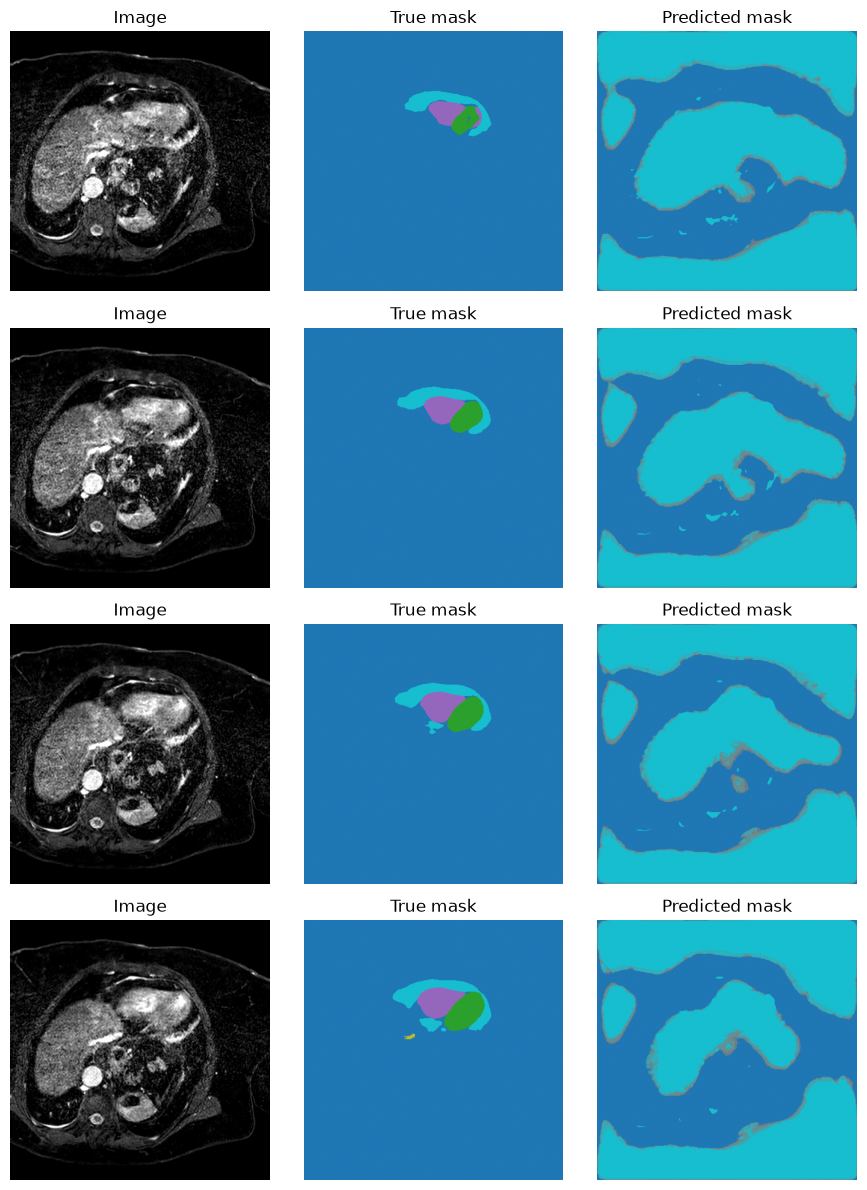

In [9]:
import matplotlib.pyplot as plt

model.eval()
batch = next(iter(val_loader))
images, true_masks = batch['image'], batch['mask']

with torch.no_grad():
    images_dev = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
    preds = model(images_dev).argmax(dim=1).cpu()

n_show = min(4, images.shape[0])
fig, ax = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
for i in range(n_show):
    ax[i, 0].imshow(images[i, 0], cmap='gray');   ax[i, 0].set_title('Image')
    ax[i, 1].imshow(true_masks[i], cmap='tab10'); ax[i, 1].set_title('True mask')
    ax[i, 2].imshow(preds[i], cmap='tab10');      ax[i, 2].set_title('Predicted mask')
    for a in ax[i]: a.axis('off')
plt.tight_layout()
plt.show()

### Per-class Dice breakdown

In [ ]:
from utils.dice_score import dice_coeff

model.eval()
class_scores = torch.zeros(model.n_classes)
class_counts = torch.zeros(model.n_classes)

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
        true_masks = batch['mask'].to(device=device, dtype=torch.long)
        preds = model(images).argmax(dim=1)

        for c in range(model.n_classes):
            pred_c = (preds == c).float()
            true_c = (true_masks == c).float()
            if true_c.sum() > 0:
                class_scores[c] += dice_coeff(pred_c, true_c, reduce_batch_first=True)
                class_counts[c] += 1

for c in range(model.n_classes):
    if class_counts[c] > 0:
        print(f'Class {c}: Dice = {class_scores[c] / class_counts[c]:.4f}')
    else:
        print(f'Class {c}: never present in validation set')